In [ ]:
# ================================================
# SwiftCargo Logistics - Dataset Generation
# Week 1: Strategic Planning & Data Exploration
# ================================================

import pandas as pd
import numpy as np

np.random.seed(42)          # keeps results same every time
n = 2000                    # number of shipments

cities     = ['Chennai', 'Bengaluru', 'Hyderabad', 'Mumbai', 'Delhi']
vehicles   = ['Bike', 'Mini Truck', 'Van', 'Heavy Truck']
categories = ['Electronics', 'Groceries', 'Apparel', 'Furniture', 'Pharma']
weather    = ['Clear', 'Rain', 'Fog', 'Storm']

data = {
    'Shipment_ID'     : ['SC' + str(10000 + i) for i in range(n)],
    'Order_Date'      : pd.to_datetime('2025-01-01') + pd.to_timedelta(
                            np.random.randint(0, 365, n), unit='D'),
    'Origin_City'     : np.random.choice(cities, n),
    'Destination_City': np.random.choice(cities, n),
    'Distance_KM'     : np.round(np.random.uniform(5, 800, n), 1),
    'Weight_KG'       : np.round(np.random.uniform(0.5, 950, n), 2),
    'Vehicle_Type'    : np.random.choice(vehicles, n),
    'Product_Category': np.random.choice(categories, n),
    'Weather'         : np.random.choice(weather, n, p=[0.6, 0.25, 0.1, 0.05]),
    'Fuel_Cost_INR'   : np.round(np.random.uniform(150, 6000, n), 2),
    'Promised_Days'   : np.random.randint(1, 8, n)
}

df = pd.DataFrame(data)

# Actual delivery time depends on distance, weather and weight
base = df['Distance_KM'] / 180
weather_delay = df['Weather'].map({'Clear': 0, 'Rain': 0.8, 'Fog': 1.2, 'Storm': 2.0})
weight_delay  = df['Weight_KG'] / 900
noise = np.random.normal(0, 0.6, n)

df['Actual_Days'] = np.round(base + weather_delay + weight_delay + noise + 1, 0)
df['Actual_Days'] = df['Actual_Days'].clip(lower=1)

df['Delivery_Status'] = np.where(df['Actual_Days'] <= df['Promised_Days'],
                                 'On-Time', 'Delayed')

df.to_csv('swiftcargo_logistics.csv', index=False)

print("Dataset created successfully!")
print("Rows:", df.shape[0], " Columns:", df.shape[1])
print("\nFirst 5 rows:\n")
print(df.head())
print("\nOn-Time vs Delayed:\n")
print(df['Delivery_Status'].value_counts())

Dataset created successfully!
Rows: 2000  Columns: 13

First 5 rows:

  Shipment_ID Order_Date Origin_City Destination_City  Distance_KM  Weight_KG  \
0     SC10000 2025-04-13      Mumbai            Delhi        677.7     123.05   
1     SC10001 2025-12-15      Mumbai           Mumbai        150.3     510.25   
2     SC10002 2025-09-28   Hyderabad        Hyderabad        765.3     889.77   
3     SC10003 2025-04-17       Delhi            Delhi        304.5     293.28   
4     SC10004 2025-03-13      Mumbai        Hyderabad        274.7     826.13   

  Vehicle_Type Product_Category Weather  Fuel_Cost_INR  Promised_Days  \
0          Van        Groceries   Clear        3678.65              3   
1          Van        Furniture    Rain        1002.24              7   
2         Bike          Apparel    Rain        4399.86              5   
3  Heavy Truck        Furniture   Clear        1363.64              4   
4         Bike        Groceries   Clear        2683.08              3   

   A

In [ ]:
# ===== KPI CALCULATION =====
on_time_rate      = (df['Delivery_Status'] == 'On-Time').mean() * 100
avg_delivery_time = df['Actual_Days'].mean()
avg_cost          = df['Fuel_Cost_INR'].mean()

delayed  = df[df['Delivery_Status'] == 'Delayed']
severity = (delayed['Actual_Days'] - delayed['Promised_Days']).mean()

print(f"KPI 1 - On-Time Delivery Rate : {on_time_rate:.2f} %")
print(f"KPI 2 - Avg Delivery Time     : {avg_delivery_time:.2f} days")
print(f"KPI 3 - Avg Cost per Shipment : Rs {avg_cost:.2f}")
print(f"KPI 4 - Delay Severity        : {severity:.2f} days")
print("\nKPI 5 - Vehicle Utilisation (avg kg):")
print(df.groupby('Vehicle_Type')['Weight_KG'].mean().round(2))

KPI 1 - On-Time Delivery Rate : 52.20 %
KPI 2 - Avg Delivery Time     : 4.19 days
KPI 3 - Avg Cost per Shipment : Rs 3083.86
KPI 4 - Delay Severity        : 2.51 days

KPI 5 - Vehicle Utilisation (avg kg):
Vehicle_Type
Bike           470.76
Heavy Truck    455.49
Mini Truck     469.42
Van            459.14
Name: Weight_KG, dtype: float64


In [ ]:
# ================================================
# Week 2: Simulating real-world "dirty" data
# ================================================
import numpy as np
import pandas as pd

np.random.seed(7)
df_raw = df.copy()   # start from the clean Week 1 dataset

# 1. Introduce missing values (simulate sensor/entry gaps)
for col in ['Distance_KM', 'Weight_KG', 'Fuel_Cost_INR', 'Weather']:
    missing_idx = df_raw.sample(frac=0.04, random_state=1).index
    df_raw.loc[missing_idx, col] = np.nan

# 2. Introduce duplicate rows (simulate double data entry)
dupes = df_raw.sample(15, random_state=2)
df_raw = pd.concat([df_raw, dupes], ignore_index=True)

# 3. Introduce outliers (simulate data entry errors)
outlier_idx = df_raw.sample(10, random_state=3).index
df_raw.loc[outlier_idx, 'Distance_KM'] = df_raw.loc[outlier_idx, 'Distance_KM'] * 15
df_raw.loc[outlier_idx[:5], 'Fuel_Cost_INR'] = df_raw.loc[outlier_idx[:5], 'Fuel_Cost_INR'] * 20

# 4. Inconsistent text formatting (simulate manual entry)
df_raw.loc[df_raw.sample(20, random_state=4).index, 'Origin_City'] = ' chennai '
df_raw.loc[df_raw.sample(15, random_state=5).index, 'Vehicle_Type'] = 'VAN'

df_raw.to_csv('swiftcargo_logistics_RAW.csv', index=False)

print("RAW dataset created (dirty version)")
print("Shape:", df_raw.shape)
print("\nMissing values per column:\n", df_raw.isnull().sum()[df_raw.isnull().sum() > 0])
print("\nDuplicate rows:", df_raw.duplicated().sum())
print("\nSample of inconsistent text:")
print(df_raw['Origin_City'].unique()[:8])

RAW dataset created (dirty version)
Shape: (2015, 13)

Missing values per column:
 Distance_KM      81
Weight_KG        81
Weather          81
Fuel_Cost_INR    81
dtype: int64

Duplicate rows: 15

Sample of inconsistent text:
['Mumbai' 'Hyderabad' 'Delhi' 'Bengaluru' 'Chennai' ' chennai ']


In [ ]:
# ================================================
# Week 2: Data Cleaning & Preprocessing Pipeline
# ================================================
df_clean = df_raw.copy()

# ---- STEP 1: Remove duplicate rows ----
before = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
print(f"Removed {before - df_clean.shape[0]} duplicate rows")

# ---- STEP 2: Fix inconsistent text formatting ----
df_clean['Origin_City']  = df_clean['Origin_City'].str.strip().str.title()
df_clean['Vehicle_Type'] = df_clean['Vehicle_Type'].str.strip().str.title()

# ---- STEP 3: Handle missing values ----
for col in ['Distance_KM', 'Weight_KG', 'Fuel_Cost_INR']:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)

df_clean['Weather'] = df_clean['Weather'].fillna(df_clean['Weather'].mode()[0])

print("\nMissing values after cleaning:", df_clean.isnull().sum().sum(), "total missing")

# ---- STEP 4: Detect and treat outliers using IQR method ----
def cap_outliers(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((data[col] < lower) | (data[col] > upper)).sum()
    data[col] = data[col].clip(lower, upper)
    return n_outliers

for col in ['Distance_KM', 'Fuel_Cost_INR']:
    n = cap_outliers(df_clean, col)
    print(f"{col}: {n} outliers capped")

# ---- STEP 5: Normalize numeric columns (Min-Max scaling) ----
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
cols_to_scale = ['Distance_KM', 'Weight_KG', 'Fuel_Cost_INR']
df_clean[[c + '_Normalized' for c in cols_to_scale]] = scaler.fit_transform(df_clean[cols_to_scale])

df_clean.to_csv('swiftcargo_logistics_CLEANED.csv', index=False)

print("\nFinal cleaned shape:", df_clean.shape)
df_clean.head()

Removed 15 duplicate rows

Missing values after cleaning: 0 total missing
Distance_KM: 9 outliers capped
Fuel_Cost_INR: 4 outliers capped

Final cleaned shape: (2000, 16)


,Shipment_ID,Order_Date,Origin_City,Destination_City,Distance_KM,Weight_KG,Vehicle_Type,Product_Category,Weather,Fuel_Cost_INR,Promised_Days,Actual_Days,Delivery_Status,Distance_KM_Normalized,Weight_KG_Normalized,Fuel_Cost_INR_Normalized
0,SC10000,2025-04-13,Mumbai,Delhi,677.7,123.05,Van,Groceries,Clear,3678.65,3,5.0,Delayed,0.577799,0.128959,0.416363
1,SC10001,2025-12-15,Mumbai,Mumbai,150.3,510.25,Van,Furniture,Rain,1002.24,7,4.0,On-Time,0.124667,0.537174,0.100434
2,SC10002,2025-09-28,Hyderabad,Hyderabad,765.3,889.77,Bike,Apparel,Rain,4399.86,5,7.0,Delayed,0.653063,0.937292,0.501496
3,SC10003,2025-04-17,Delhi,Delhi,304.5,293.28,Heavy Truck,Furniture,Clear,1363.64,4,3.0,On-Time,0.257153,0.308428,0.143094
4,SC10004,2025-03-13,Mumbai,Hyderabad,274.7,826.13,Bike,Groceries,Clear,2683.08,3,3.0,On-Time,0.231549,0.870198,0.298844


In [6]:
# ================================================
# Week 3: Exploratory Data Analysis (EDA)
# ================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# ---- Central Tendency & Spread ----
print("=== DESCRIPTIVE STATISTICS ===")
print(df_clean[['Distance_KM', 'Weight_KG', 'Fuel_Cost_INR', 'Actual_Days']].describe().round(2))

# ---- Correlation Matrix ----
print("\n=== CORRELATION MATRIX ===")
num_cols = ['Distance_KM', 'Weight_KG', 'Fuel_Cost_INR', 'Promised_Days', 'Actual_Days']
print(df_clean[num_cols].corr().round(2))

=== DESCRIPTIVE STATISTICS ===
       Distance_KM  Weight_KG  Fuel_Cost_INR  Actual_Days
count      2000.00    2000.00        2000.00      2000.00
mean        404.11     464.30        3102.36         4.19
std         229.89     265.50        1668.78         1.60
min           5.20       0.73         151.41         1.00
25%         211.48     240.81        1693.08         3.00
50%         398.20     457.02        3093.86         4.00
75%         594.52     683.75        4465.03         5.00
max        1169.10     949.25        8622.96         9.00

=== CORRELATION MATRIX ===
               Distance_KM  Weight_KG  Fuel_Cost_INR  Promised_Days  \
Distance_KM           1.00       0.01          -0.01          -0.01   
Weight_KG             0.01       1.00           0.01          -0.02   
Fuel_Cost_INR        -0.01       0.01           1.00          -0.04   
Promised_Days        -0.01      -0.02          -0.04           1.00   
Actual_Days           0.77       0.18          -0.01           0

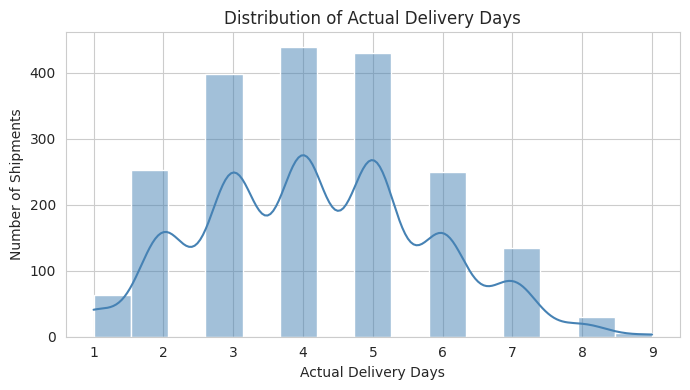

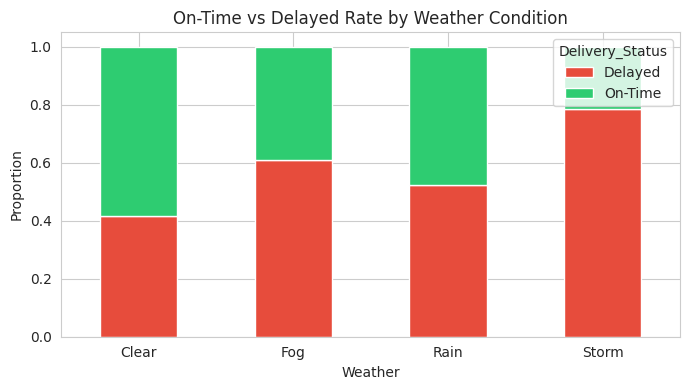

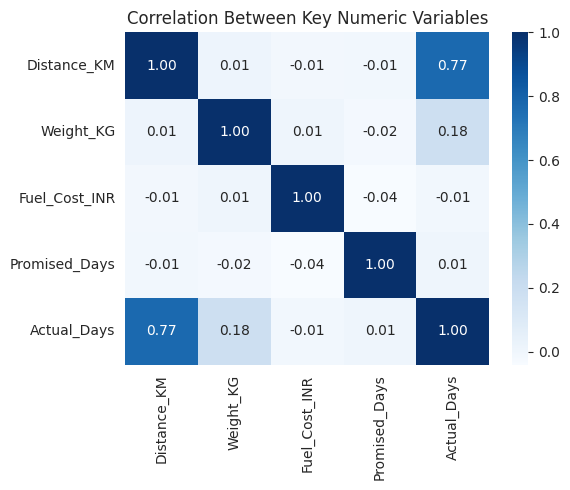

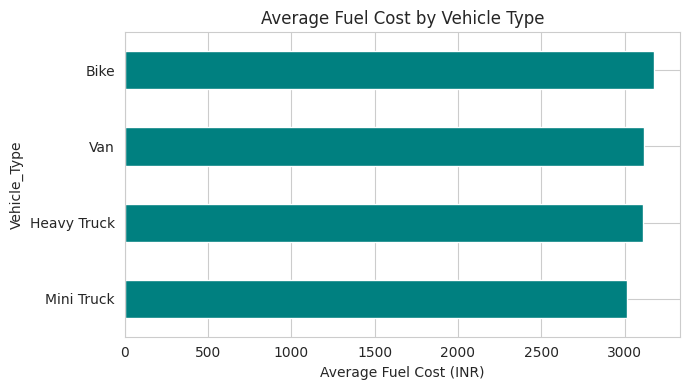

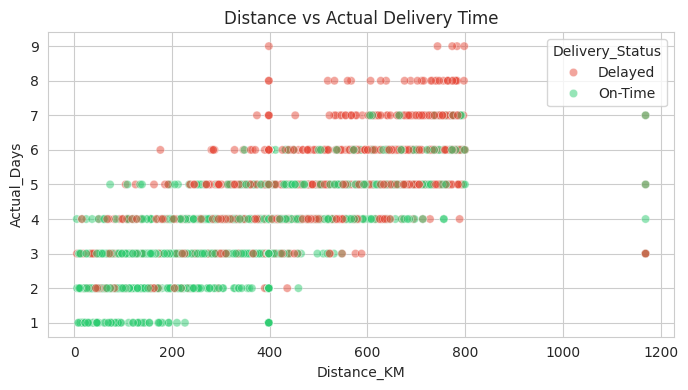

/tmp/ipykernel_530/896068260.py:39: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  city_rate = df_clean.groupby('Origin_City').apply(


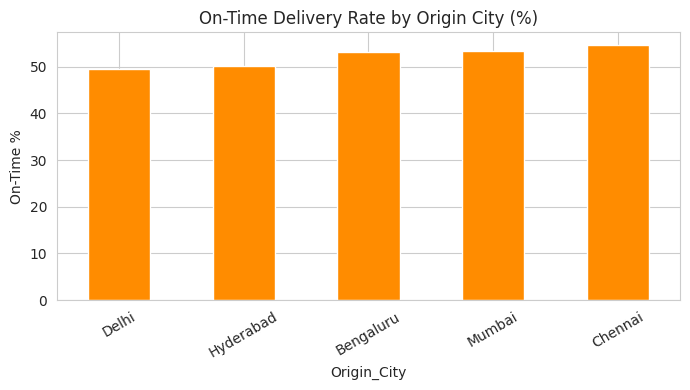

All 6 charts saved!


In [7]:
# ---- CHART 1: Distribution of Delivery Time ----
plt.figure(figsize=(7,4))
sns.histplot(df_clean['Actual_Days'], bins=15, kde=True, color='steelblue')
plt.title('Distribution of Actual Delivery Days')
plt.xlabel('Actual Delivery Days'); plt.ylabel('Number of Shipments')
plt.tight_layout(); plt.savefig('chart1_delivery_distribution.png'); plt.show()

# ---- CHART 2: Delivery Status by Weather ----
plt.figure(figsize=(7,4))
pd.crosstab(df_clean['Weather'], df_clean['Delivery_Status'], normalize='index').plot(
    kind='bar', stacked=True, color=['#e74c3c','#2ecc71'], ax=plt.gca())
plt.title('On-Time vs Delayed Rate by Weather Condition')
plt.ylabel('Proportion'); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig('chart2_weather_delay.png'); plt.show()

# ---- CHART 3: Correlation Heatmap ----
plt.figure(figsize=(6,5))
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Between Key Numeric Variables')
plt.tight_layout(); plt.savefig('chart3_correlation_heatmap.png'); plt.show()

# ---- CHART 4: Avg Fuel Cost by Vehicle Type ----
plt.figure(figsize=(7,4))
df_clean.groupby('Vehicle_Type')['Fuel_Cost_INR'].mean().sort_values().plot(
    kind='barh', color='teal')
plt.title('Average Fuel Cost by Vehicle Type')
plt.xlabel('Average Fuel Cost (INR)')
plt.tight_layout(); plt.savefig('chart4_cost_by_vehicle.png'); plt.show()

# ---- CHART 5: Distance vs Delivery Time (scatter) ----
plt.figure(figsize=(7,4))
sns.scatterplot(data=df_clean, x='Distance_KM', y='Actual_Days', hue='Delivery_Status',
                 palette={'On-Time':'#2ecc71','Delayed':'#e74c3c'}, alpha=0.5)
plt.title('Distance vs Actual Delivery Time')
plt.tight_layout(); plt.savefig('chart5_distance_vs_time.png'); plt.show()

# ---- CHART 6: On-Time Rate by City ----
plt.figure(figsize=(7,4))
city_rate = df_clean.groupby('Origin_City').apply(
    lambda x: (x['Delivery_Status']=='On-Time').mean()*100)
city_rate.sort_values().plot(kind='bar', color='darkorange')
plt.title('On-Time Delivery Rate by Origin City (%)')
plt.ylabel('On-Time %'); plt.xticks(rotation=30)
plt.tight_layout(); plt.savefig('chart6_ontime_by_city.png'); plt.show()

print("All 6 charts saved!")


In [8]:
# ================================================
# Week 4: Predictive Modeling
# ================================================
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                              accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix)
import numpy as np

df_model = df_clean.copy()

# ---- Prepare features ----
X = pd.get_dummies(df_model[['Distance_KM', 'Weight_KG', 'Vehicle_Type',
                              'Product_Category', 'Weather', 'Origin_City']])
y_reg = df_model['Actual_Days']                      # Regression target
y_clf = df_model['Delivery_Status']                   # Classification target

# ---- Train-test split (80/20) ----
X_train, X_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42)

_, _, y_clf_train, y_clf_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42)

# ============================================================
# MODEL 1: Regression - Predict Actual_Days
# ============================================================
print("="*55)
print("REGRESSION MODEL: Predicting Delivery Duration")
print("="*55)

lr = LinearRegression()
lr.fit(X_train, y_reg_train)
lr_pred = lr.predict(X_test)

rf_reg = RandomForestRegressor(n_estimators=200, random_state=42)
rf_reg.fit(X_train, y_reg_train)
rf_pred = rf_reg.predict(X_test)

for name, pred in [('Linear Regression', lr_pred), ('Random Forest', rf_pred)]:
    mae = mean_absolute_error(y_reg_test, pred)
    rmse = np.sqrt(mean_squared_error(y_reg_test, pred))
    r2 = r2_score(y_reg_test, pred)
    print(f"\n{name}:")
    print(f"  MAE  : {mae:.3f} days")
    print(f"  RMSE : {rmse:.3f} days")
    print(f"  R2   : {r2:.3f}")

# Cross-validation
cv_scores = cross_val_score(rf_reg, X, y_reg, cv=5, scoring='r2')
print(f"\n5-Fold CV R2 scores: {cv_scores.round(3)}")
print(f"Mean CV R2: {cv_scores.mean():.3f}")

# Feature importance
importance = pd.Series(rf_reg.feature_importances_, index=X.columns).sort_values(ascending=False)
print("\nTop 8 Most Important Features (Regression):")
print(importance.head(8).round(3))

# ============================================================
# MODEL 2: Classification - Predict Delivery_Status
# ============================================================
print("\n" + "="*55)
print("CLASSIFICATION MODEL: Predicting Delay Risk")
print("="*55)

rf_clf = RandomForestClassifier(n_estimators=200, random_state=42)
rf_clf.fit(X_train, y_clf_train)
clf_pred = rf_clf.predict(X_test)

acc = accuracy_score(y_clf_test, clf_pred)
prec = precision_score(y_clf_test, clf_pred, pos_label='Delayed')
rec = recall_score(y_clf_test, clf_pred, pos_label='Delayed')
f1 = f1_score(y_clf_test, clf_pred, pos_label='Delayed')

print(f"Accuracy  : {acc:.3f}")
print(f"Precision (Delayed): {prec:.3f}")
print(f"Recall (Delayed)   : {rec:.3f}")
print(f"F1-Score (Delayed) : {f1:.3f}")

print("\nConfusion Matrix:")
cm = confusion_matrix(y_clf_test, clf_pred, labels=['On-Time', 'Delayed'])
print(pd.DataFrame(cm, index=['Actual On-Time','Actual Delayed'],
                    columns=['Pred On-Time','Pred Delayed']))

REGRESSION MODEL: Predicting Delivery Duration

Linear Regression:
  MAE  : 0.625 days
  RMSE : 0.880 days
  R2   : 0.691

Random Forest:
  MAE  : 0.649 days
  RMSE : 0.854 days
  R2   : 0.709

5-Fold CV R2 scores: [0.744 0.734 0.721 0.752 0.714]
Mean CV R2: 0.733

Top 8 Most Important Features (Regression):
Distance_KM                   0.689
Weather_Clear                 0.112
Weight_KG                     0.080
Weather_Storm                 0.011
Weather_Rain                  0.010
Vehicle_Type_Heavy Truck      0.009
Origin_City_Delhi             0.008
Product_Category_Furniture    0.008
dtype: float64

CLASSIFICATION MODEL: Predicting Delay Risk
Accuracy  : 0.620
Precision (Delayed): 0.613
Recall (Delayed)   : 0.600
F1-Score (Delayed) : 0.606

Confusion Matrix:
                Pred On-Time  Pred Delayed
Actual On-Time           131            74
Actual Delayed            78           117


In [ ]:
from google.colab import drive
drive.mount('/content/drive')